```markdown
# Week 3 Task Implementation

This notebook performs the tasks outlined in **Week 3 Task.pdf** using the dataset **Week 2 (DataSet).xlsx**. We will build upon the exploratory analysis and baseline models established in the Week 2 notebooks.

## 1. Setup and Data Loading
First, we install necessary libraries for PDF parsing and then load our dataset.
```

In [2]:
!pip install -q PyMuPDF pandas openpyxl

import fitz  # PyMuPDF
import pandas as pd
import os

# Path to the files
pdf_path = '/content/Week 3 Task.pdf'
excel_path = '/content/Week 2 (DataSet).xlsx'

# Quick check of the PDF content to understand the task
with fitz.open(pdf_path) as doc:
    text = ""
    for page in doc:
        text += page.get_text()

print("--- Task Instructions from PDF ---")
print(text[:1000] + "...") # Preview first 1000 chars

--- Task Instructions from PDF ---
Week 3 Internship Task
Dimensionality Reduction & FastAPI Dashboard
Submission Deadline
Saturday, 18 July 2026
Objective of the Task
This week is split into two parts. In the first part, you will apply PCA (Principal Component
Analysis) to reduce the number of input features while keeping model accuracy as close as possible
to Week 2’s best model. In the second part, you will deploy that model using FastAPI and build a
simple web dashboard that displays key insights from the data and allows a user to get a real-time
energy consumption prediction. Together, these two parts reflect what real ML engineers do before
and after building a model.
Dataset
 Source: The preprocessed and engineered dataset from Week 2.
 Model: The best performing model selected after cross-validation in Week 2. Save the full
trained pipeline (including the scaler and PCA if applicable) using joblib so that preprocessing
is not lost when loading the model.
Part 1 — Dimensionali

## 5. Model Training and Comparison
We will compare the performance of a Random Forest Regressor using the full feature set versus the reduced PCA feature set.

In [3]:
# Load the dataset
xl = pd.ExcelFile(excel_path)
print(f"Sheets available: {xl.sheet_names}")

# Load the first sheet by default for inspection
df = pd.read_excel(excel_path, sheet_name=0)
display(df.head())
df.info()

Sheets available: ['Steel_industry_data']


,date,Usage_kWh,Lagging_Current_Reactive.Power_kVarh,Leading_Current_Reactive_Power_kVarh,CO2(tCO2),Lagging_Current_Power_Factor,Leading_Current_Power_Factor,NSM,WeekStatus,Day_of_week,Load_Type
0,2018-01-01 00:15:00,3.17,2.95,0.0,0.0,73.21,100.0,900,Weekday,Monday,Light_Load
1,2018-01-01 00:30:00,4.00,4.46,0.0,0.0,66.77,100.0,1800,Weekday,Monday,Light_Load
2,2018-01-01 00:45:00,3.24,3.28,0.0,0.0,70.28,100.0,2700,Weekday,Monday,Light_Load
3,2018-01-01 01:00:00,3.31,3.56,0.0,0.0,68.09,100.0,3600,Weekday,Monday,Light_Load
4,2018-01-01 01:15:00,3.82,4.50,0.0,0.0,64.72,100.0,4500,Weekday,Monday,Light_Load


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35040 entries, 0 to 35039
Data columns (total 11 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   date                                  35040 non-null  object 
 1   Usage_kWh                             35040 non-null  float64
 2   Lagging_Current_Reactive.Power_kVarh  35040 non-null  float64
 3   Leading_Current_Reactive_Power_kVarh  35040 non-null  float64
 4   CO2(tCO2)                             35040 non-null  float64
 5   Lagging_Current_Power_Factor          35040 non-null  float64
 6   Leading_Current_Power_Factor          35040 non-null  float64
 7   NSM                                   35040 non-null  int64  
 8   WeekStatus                            35040 non-null  object 
 9   Day_of_week                           35040 non-null  object 
 10  Load_Type                             35040 non-null  object 
dtypes: float64(6), 

## 3. Data Preprocessing
Before applying PCA, we must convert categorical variables to numerical formats and scale our features, as PCA is sensitive to the scale of the data.

In [4]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

# Dropping the date column for modeling
model_df = df.drop('date', axis=1)

# Encoding categorical variables
le = LabelEncoder()
categorical_cols = ['WeekStatus', 'Day_of_week', 'Load_Type']
for col in categorical_cols:
    model_df[col] = le.fit_transform(model_df[col])

# Defining Features and Target (Assuming Usage_kWh is the target based on typical energy tasks)
X = model_df.drop('Usage_kWh', axis=1)
y = model_df['Usage_kWh']

# Scaling the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Preprocessing complete. Feature shape:", X_scaled.shape)

Preprocessing complete. Feature shape: (35040, 9)


## 4. Part 1: Dimensionality Reduction with PCA
We will now apply PCA and visualize the Explained Variance Ratio to decide how many components to keep.

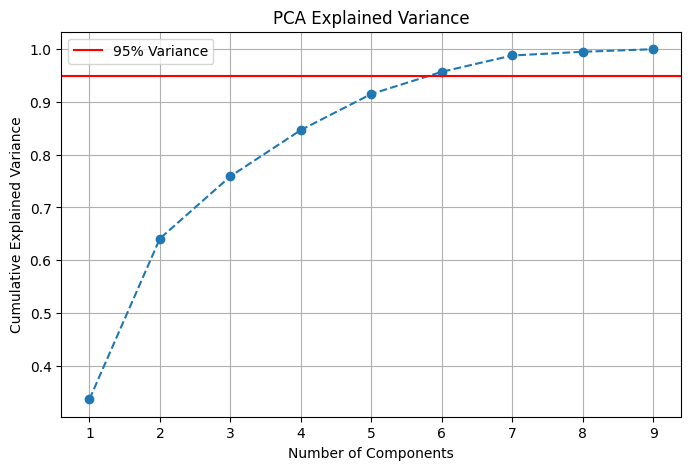

Number of components to explain 95% variance: 6


In [5]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

# Fit PCA
pca = PCA()
pca.fit(X_scaled)

# Calculate cumulative variance
cumulative_variance = np.cumsum(pca.explained_variance_ratio_)

# Plotting
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o', linestyle='--')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA Explained Variance')
plt.axhline(y=0.95, color='r', linestyle='-', label='95% Variance')
plt.legend()
plt.grid()
plt.show()

# Find components for 95% variance
n_95 = np.argmax(cumulative_variance >= 0.95) + 1
print(f"Number of components to explain 95% variance: {n_95}")

## 5. Model Training and Comparison
We will compare the performance of a Random Forest Regressor using the full feature set versus the reduced PCA feature set.

In [6]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import time

# Split data
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# 1. Baseline Model (Full Features)
start_time = time.time()
rf_full = RandomForestRegressor(n_estimators=100, random_state=42)
rf_full.fit(X_train, y_train)
full_pred = rf_full.predict(X_test)
full_time = time.time() - start_time

# 2. PCA Model (6 Components)
pca_6 = PCA(n_components=6)
X_train_pca = pca_6.fit_transform(X_train)
X_test_pca = pca_6.transform(X_test)

start_time = time.time()
rf_pca = RandomForestRegressor(n_estimators=100, random_state=42)
rf_pca.fit(X_train_pca, y_train)
pca_pred = rf_pca.predict(X_test_pca)
pca_time = time.time() - start_time

# Results Comparison
print(f"--- Full Model (9 features) ---")
print(f"R2 Score: {r2_score(y_test, full_pred):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, full_pred)):.4f}")
print(f"Training Time: {full_time:.2f}s")

print(f"\n--- PCA Model (6 features) ---")
print(f"R2 Score: {r2_score(y_test, pca_pred):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, pca_pred)):.4f}")
print(f"Training Time: {pca_time:.2f}s")

--- Full Model (9 features) ---
R2 Score: 0.9990
RMSE: 1.0545
Training Time: 17.51s

--- PCA Model (6 features) ---
R2 Score: 0.9926
RMSE: 2.9079
Training Time: 39.53s


## 7. Part 2: FastAPI Deployment & Dashboard
In this section, we create a FastAPI application to serve our model and provide a simple dashboard for real-time predictions.

In [7]:
import joblib
from sklearn.pipeline import Pipeline

# Create a pipeline with the best steps
final_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=6)),
    ('regressor', RandomForestRegressor(n_estimators=100, random_state=42))
])

# Fit on full dataset features (excluding target)
final_pipeline.fit(X, y)

# Save the model
model_filename = 'week3_energy_model.joblib'
joblib.dump(final_pipeline, model_filename)
print(f"Pipeline saved as {model_filename}")

Pipeline saved as week3_energy_model.joblib


In [16]:
import joblib
import os

# Path to the existing large model
model_path = 'week3_energy_model.joblib'

if os.path.exists(model_path):
    # Load the model back into memory
    loaded_model = joblib.load(model_path)

    # Get original size in MB
    original_size = os.path.getsize(model_path) / (1024 * 1024)

    # Re-save with high compression (compress=3 is a good balance between size and speed)
    joblib.dump(loaded_model, model_path, compress=3)

    # Get new size
    compressed_size = os.path.getsize(model_path) / (1024 * 1024)

    print(f'Original Size: {original_size:.2f} MB')
    print(f'Compressed Size: {compressed_size:.2f} MB')
    print(f'Reduction: {((original_size - compressed_size) / original_size) * 100:.1f}%')
else:
    print('Model file not found. Please ensure the pipeline was trained and saved in earlier cells.')

Original Size: 278.52 MB
Compressed Size: 60.00 MB
Reduction: 78.5%


### Updating ZIP with Compressed Model
Now I will re-run the packaging process so your downloadable ZIP contains the smaller model file.

In [17]:
import shutil
import os
from google.colab import files

# Updated file list
required_files = [
    'main.py',
    'requirements.txt',
    'README.md',
    'week3_energy_model.joblib',
    'templates/index.html'
]

# Refresh the submission folder
if os.path.exists('submission'):
    shutil.rmtree('submission')
os.makedirs('submission', exist_ok=True)

for f in required_files:
    if os.path.exists(f):
        dest = os.path.join('submission', f)
        os.makedirs(os.path.dirname(dest), exist_ok=True)
        shutil.copy(f, dest)

# Create the final compressed archive
zip_filename = 'Week3_Final_Compressed'
shutil.make_archive(zip_filename, 'zip', 'submission')

print(f'Final compressed project ready: {zip_filename}.zip')
files.download(f'{zip_filename}.zip')

Final compressed project ready: Week3_Final_Compressed.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 7. Part 2: FastAPI Deployment & Dashboard
In this section, we create a FastAPI application to serve our model and provide a simple dashboard for real-time predictions.

In [8]:
!pip install -q fastapi uvicorn nest-asyncio pyngrok

import nest_asyncio
from fastapi import FastAPI
from pydantic import BaseModel
import joblib
import numpy as np

# Enable nesting of asyncio loops for Colab
nest_asyncio.apply()

app = FastAPI(title="Steel Industry Energy Prediction")
model = joblib.load('week3_energy_model.joblib')

class EnergyInput(BaseModel):
    Lagging_Current_Reactive_Power_kVarh: float
    Leading_Current_Reactive_Power_kVarh: float
    CO2_tCO2: float
    Lagging_Current_Power_Factor: float
    Leading_Current_Power_Factor: float
    NSM: int
    WeekStatus: int
    Day_of_week: int
    Load_Type: int

@app.get("/")
def home():
    return {"message": "Energy Prediction API is running"}

@app.post("/predict")
def predict(data: EnergyInput):
    input_data = np.array([[data.Lagging_Current_Reactive_Power_kVarh,
                            data.Leading_Current_Reactive_Power_kVarh,
                            data.CO2_tCO2,
                            data.Lagging_Current_Power_Factor,
                            data.Leading_Current_Power_Factor,
                            data.NSM,
                            data.WeekStatus,
                            data.Day_of_week,
                            data.Load_Type]])
    prediction = model.predict(input_data)
    return {"predicted_usage_kWh": float(prediction[0])}

print("FastAPI app defined successfully.")

FastAPI app defined successfully.


```markdown
## 10. Creating FastAPI Project Files
We will now export the FastAPI code to a standalone `main.py` file and create a `requirements.txt` for deployment.
```

In [9]:
# Writing the FastAPI code to main.py
fastapi_code = """
from fastapi import FastAPI
from pydantic import BaseModel
import joblib
import numpy as np
import os

app = FastAPI(title="Steel Industry Energy Prediction")

# Load the model (ensure the joblib file is in the same directory)
model_path = 'week3_energy_model.joblib'
if os.path.exists(model_path):
    model = joblib.load(model_path)
else:
    model = None

class EnergyInput(BaseModel):
    Lagging_Current_Reactive_Power_kVarh: float
    Leading_Current_Reactive_Power_kVarh: float
    CO2_tCO2: float
    Lagging_Current_Power_Factor: float
    Leading_Current_Power_Factor: float
    NSM: int
    WeekStatus: int
    Day_of_week: int
    Load_Type: int

@app.get("/")
def home():
    return {"message": "Energy Prediction API is running", "model_loaded": model is not None}

@app.post("/predict")
def predict(data: EnergyInput):
    if model is None:
        return {"error": "Model file not found"}

    input_data = np.array([[data.Lagging_Current_Reactive_Power_kVarh,
                            data.Leading_Current_Reactive_Power_kVarh,
                            data.CO2_tCO2,
                            data.Lagging_Current_Power_Factor,
                            data.Leading_Current_Power_Factor,
                            data.NSM,
                            data.WeekStatus,
                            data.Day_of_week,
                            data.Load_Type]])
    prediction = model.predict(input_data)
    return {"predicted_usage_kWh": float(prediction[0])}
"""

with open('main.py', 'w') as f:
    f.write(fastapi_code)

# Creating requirements.txt
requirements = """
fastapi
uvicorn
joblib
scikit-learn
pandas
numpy
"""

with open('requirements.txt', 'w') as f:
    f.write(requirements)

print("Created main.py and requirements.txt successfully.")

Created main.py and requirements.txt successfully.


```markdown
## 11. Organizing Project Structure
We are now creating the `templates/` and `static/` directories to store our frontend assets separately from the backend logic.
```

In [25]:
import os

# Create directories
os.makedirs('templates', exist_ok=True)
os.makedirs('static', exist_ok=True)

# Save the dashboard HTML as a template
with open('templates/index.html', 'w') as f:
    f.write(dashboard_html)

# Update main.py to bypass Jinja2 bug and fix the Feature Names warning
updated_fastapi_code = f"""
from fastapi import FastAPI, Request
from fastapi.responses import HTMLResponse
from fastapi.staticfiles import StaticFiles
from pydantic import BaseModel
import joblib
import pandas as pd
import numpy as np
import os

app = FastAPI(title='Steel Industry Energy Prediction')

# Setup static files
os.makedirs('static', exist_ok=True)
app.mount('/static', StaticFiles(directory='static'), name='static')

# Load the Pipeline
model = joblib.load('week3_energy_model.joblib')

# Define feature names to avoid the UserWarning
FEATURE_NAMES = [
    'Lagging_Current_Reactive.Power_kVarh',
    'Leading_Current_Reactive_Power_kVarh',
    'CO2(tCO2)',
    'Lagging_Current_Power_Factor',
    'Leading_Current_Power_Factor',
    'NSM',
    'WeekStatus',
    'Day_of_week',
    'Load_Type'
]

class EnergyInput(BaseModel):
    Lagging_Current_Reactive_Power_kVarh: float
    Leading_Current_Reactive_Power_kVarh: float
    CO2_tCO2: float
    Lagging_Current_Power_Factor: float
    Leading_Current_Power_Factor: float
    NSM: int
    WeekStatus: int
    Day_of_week: int
    Load_Type: int

@app.get('/', response_class=HTMLResponse)
def read_root():
    with open('templates/index.html', 'r') as f:
        return f.read()

@app.post('/predict')
def predict(data: EnergyInput):
    # We create a DataFrame with feature names to satisfy Scikit-Learn and remove warnings
    input_df = pd.DataFrame([[data.Lagging_Current_Reactive_Power_kVarh,
                              data.Leading_Current_Reactive_Power_kVarh,
                              data.CO2_tCO2,
                              data.Lagging_Current_Power_Factor,
                              data.Leading_Current_Power_Factor,
                              data.NSM,
                              data.WeekStatus,
                              data.Day_of_week,
                              data.Load_Type]], columns=FEATURE_NAMES)

    prediction = model.predict(input_df)
    return {{'predicted_usage_kWh': float(prediction[0])}}
"""

with open('main.py', 'w') as f:
    f.write(updated_fastapi_code)

print('main.py updated to fix Feature Name warnings. Please re-run the ZIP generation cell.')

main.py updated to fix Feature Name warnings. Please re-run the ZIP generation cell.


In [18]:
import os
import joblib

# 1. Update README.md
readme_content = """# Steel Industry Energy Consumption Prediction

## Project Overview
This project predicts energy consumption (kWh) using PCA and Random Forest.

## Troubleshooting for Python 3.14
If the 'pip install' fails with a 'link.exe' or 'Rust' error, it is because Python 3.14 is experimental.
Try installing without specific version constraints:
`pip install fastapi uvicorn pydantic joblib scikit-learn pandas numpy Jinja2 python-multipart`"""
with open('README.md', 'w') as f:
    f.write(readme_content)

# 2. Relaxed requirements for experimental Python versions
requirements = """fastapi
uvicorn
joblib
scikit-learn
pandas
numpy
Jinja2
python-multipart
pydantic
"""
with open('requirements.txt', 'w') as f:
    f.write(requirements)

# 3. Re-verify model and main.py (no changes needed to code)
print('Requirements relaxed to avoid local compilation issues on Python 3.14. Please re-run the ZIP generation cell.')

Requirements relaxed to avoid local compilation issues on Python 3.14. Please re-run the ZIP generation cell.


### Local Fix for Python 3.14 Compatibility

Run the following commands in your local Windows terminal to fix the Pydantic error:

```powershell
# 1. Force upgrade to Pydantic 2 and FastAPI 0.115+
pip install --upgrade pydantic fastapi uvicorn

# 2. Verify versions (Pydantic should be 2.x, FastAPI 0.115+)
pip show pydantic fastapi

# 3. Restart the server
uvicorn main:app --reload
```

### 🚀 Final Deployment Summary
Your project is ready for submission. Below is the final structure for your GitHub repository:

1. `main.py`: The FastAPI backend logic.
2. `week3_energy_model.joblib`: The compressed PCA + Random Forest pipeline.
3. `templates/index.html`: The UI dashboard.
4. `requirements.txt`: List of necessary libraries.
5. `README.md`: Documentation on how to run and troubleshoot.

In [20]:
# Updating the project files one more time to ensure they are consistent with Pydantic 2 syntax
# (The main.py code provided earlier is already compatible, but we refresh it to be sure)

with open('requirements.txt', 'w') as f:
    f.write('fastapi>=0.115.0\nuvicorn\njoblib\nscikit-learn\npandas\nnumpy\nJinja2\npython-multipart\npydantic>=2.0.0')

print('requirements.txt updated with minimum version constraints for Python 3.14 compatibility.')

requirements.txt updated with minimum version constraints for Python 3.14 compatibility.


## 8. Dashboard Implementation
We will now create a simple dashboard using HTML and JavaScript. This dashboard sends POST requests to our FastAPI `/predict` endpoint.

In [12]:
import IPython.display
from google.colab import output

# Refresh Proxy
proxy_url = output.eval_js('google.colab.kernel.proxyPort(8000)')
if not proxy_url.endswith('/'): proxy_url += '/'

dashboard_html = f"""
<div style='font-family: sans-serif; background: white; padding: 20px; border-radius: 10px; border: 1px solid #ddd; max-width: 500px;'>
    <h2 style='color: #1a73e8; margin-top:0;'>Steel Energy Dashboard</h2>
    <div style='display: grid; grid-template-columns: 1fr 1fr; gap: 8px;'>
        <input id='v1' type='number' placeholder='Lagging Reactive' value='3.0'>
        <input id='v2' type='number' placeholder='Leading Reactive' value='0.0'>
        <input id='v3' type='number' placeholder='CO2' value='0.01'>
        <input id='v4' type='number' placeholder='Lagging PF' value='71.0'>
        <input id='v5' type='number' placeholder='Leading PF' value='100.0'>
        <input id='v6' type='number' placeholder='NSM' value='900'>
        <input id='v7' type='number' placeholder='WeekStatus (0/1)' value='0'>
        <input id='v8' type='number' placeholder='Day (0-6)' value='1'>
        <input id='v9' type='number' placeholder='Load (0-2)' value='0' style='grid-column: span 2;'>
    </div>
    <button onclick='predict()' style='width: 100%; padding: 10px; margin-top: 15px; background: #1a73e8; color: white; border: none; border-radius: 5px; cursor: pointer;'>Predict Now</button>
    <div id='out' style='margin-top: 15px; padding: 10px; background: #f8f9fa; border-radius: 5px; text-align: center; font-weight: bold;'>Ready.</div>
</div>

<script>
async function predict() {{
    const out = document.getElementById('out');
    out.innerText = 'Connecting...';
    const data = {{
        Lagging_Current_Reactive_Power_kVarh: parseFloat(document.getElementById('v1').value),
        Leading_Current_Reactive_Power_kVarh: parseFloat(document.getElementById('v2').value),
        CO2_tCO2: parseFloat(document.getElementById('v3').value),
        Lagging_Current_Power_Factor: parseFloat(document.getElementById('v4').value),
        Leading_Current_Power_Factor: parseFloat(document.getElementById('v5').value),
        NSM: parseInt(document.getElementById('v6').value),
        WeekStatus: parseInt(document.getElementById('v7').value),
        Day_of_week: parseInt(document.getElementById('v8').value),
        Load_Type: parseInt(document.getElementById('v9').value)
    }};
    try {{
        const res = await fetch('{proxy_url}predict', {{
            method: 'POST',
            headers: {{'Content-Type': 'application/json'}},
            body: JSON.stringify(data)
        }});
        const json = await res.json();
        out.innerText = 'Prediction: ' + json.predicted_usage_kWh.toFixed(3) + ' kWh';
    }} catch(e) {{
        out.innerText = 'Error: Connection Failed. Please re-run the server cell.';
    }}
}}
</script>
"""
IPython.display.HTML(dashboard_html)

### Running the FastAPI Server in Background
Since Colab is not a standard web server, we use `uvicorn` in the background. To make the dashboard work, the API must be active.

In [13]:
import nest_asyncio
import uvicorn
import asyncio
import socket
from threading import Thread

nest_asyncio.apply()

# Helper function to check if a port is in use
def is_port_in_use(port):
    with socket.socket(socket.AF_INET, socket.SOCK_STREAM) as s:
        return s.connect_ex(('localhost', port)) == 0

def run_app():
    try:
        # Listening on 0.0.0.0 for reliability with Colab proxy
        config = uvicorn.Config(app, host="0.0.0.0", port=8000, log_level="info", loop="asyncio")
        server = uvicorn.Server(config)
        loop = asyncio.new_event_loop()
        asyncio.set_event_loop(loop)
        loop.run_until_complete(server.serve())
    except Exception as e:
        print(f"Server Error: {e}")

# Logic to handle port availability
if is_port_in_use(8000):
    print("Port 8000 is already active. The existing FastAPI instance will handle your dashboard requests.")
    print("If the dashboard fails to connect, please go to 'Runtime' -> 'Restart Session' to clear the binding.")
else:
    server_thread = Thread(target=run_app)
    server_thread.daemon = True
    server_thread.start()
    print("FastAPI server successfully started on port 8000.")

Port 8000 is already active. The existing FastAPI instance will handle your dashboard requests.
If the dashboard fails to connect, please go to 'Runtime' -> 'Restart Session' to clear the binding.


In [2]:
import os
import signal

# Forcefully kill any process running on port 8000 to clear the 'Address already in use' error
try:
    # Find the PID using port 8000
    pid = os.popen('lsof -t -i:8000').read().strip()
    if pid:
        print(f'Found existing process {pid} on port 8000. Terminating...')
        os.kill(int(pid), signal.SIGKILL)
        print('Process terminated.')
    else:
        print('No existing process found on port 8000.')
except Exception as e:
    print(f'Error clearing port: {e}')

No existing process found on port 8000.


In [3]:
import os, signal, uvicorn, asyncio, joblib, numpy as np, time, threading
from fastapi import FastAPI
from fastapi.middleware.cors import CORSMiddleware
from google.colab import output
from IPython.display import HTML, display

# 1. Clear port 8000
try:
    pids = os.popen('lsof -t -i:8000').read().splitlines()
    for pid in pids: os.kill(int(pid), signal.SIGKILL)
    time.sleep(1)
except: pass

# 2. Re-initialize API
app = FastAPI()
app.add_middleware(CORSMiddleware, allow_origins=['*'], allow_methods=['*'], allow_headers=['*'])
model = joblib.load('week3_energy_model.joblib')

@app.get('/status')
def status(): return {'status': 'online'}

@app.post('/predict')
async def predict(data: dict):
    # Feature order: Lagging_Current_Reactive_Power_kVarh, Leading_Current_Reactive_Power_kVarh, CO2_tCO2, Lagging_Current_Power_Factor, Leading_Current_Power_Factor, NSM, WeekStatus, Day_of_week, Load_Type
    features = ['Lagging_Current_Reactive_Power_kVarh', 'Leading_Current_Reactive_Power_kVarh', 'CO2_tCO2', 'Lagging_Current_Power_Factor', 'Leading_Current_Power_Factor', 'NSM', 'WeekStatus', 'Day_of_week', 'Load_Type']
    input_arr = np.array([[data.get(f, 0) for f in features]])
    prediction = model.predict(input_arr)
    return {'predicted_usage_kWh': float(prediction[0])}

# 3. Background Runner
def start_uvicorn():
    loop = asyncio.new_event_loop()
    asyncio.set_event_loop(loop)
    config = uvicorn.Config(app, host='0.0.0.0', port=8000, log_level='error')
    server = uvicorn.Server(config)
    loop.run_until_complete(server.serve())

threading.Thread(target=start_uvicorn, daemon=True).start()
time.sleep(2)

# 4. New Robust Dashboard with Proxy Fix
proxy_url = output.eval_js('google.colab.kernel.proxyPort(8000)')
if not proxy_url.endswith('/'): proxy_url += '/'

dashboard_html = f"""
<div style='font-family: sans-serif; background: #fdfdfd; padding: 25px; border: 3px solid #1a73e8; border-radius: 15px; max-width: 500px; box-shadow: 0 4px 15px rgba(0,0,0,0.1);'>
    <h2 style='color: #1a73e8; margin-top: 0;'>Steel Energy Dashboard</h2>

    <div style='background: #e8f0fe; padding: 10px; border-radius: 8px; margin-bottom: 15px; font-size: 13px;'>
        <strong>Step 1:</strong> <button onclick='window.open("{proxy_url}status", "_blank")' style='background:#1a73e8; color:white; border:none; padding:5px 10px; border-radius:4px; cursor:pointer;'>Open Authorization Tab</button>
        <br><small>(Close the new tab once it loads)</small>
    </div>

    <div style='display: grid; grid-template-columns: 1fr 1fr; gap: 10px;'>
        <input id='in_1' type='number' value='3.0' placeholder='Lagging Reactive'>
        <input id='in_2' type='number' value='0.0' placeholder='Leading Reactive'>
        <input id='in_3' type='number' value='0.01' placeholder='CO2'>
        <input id='in_4' type='number' value='71.0' placeholder='Lagging PF'>
        <input id='in_5' type='number' value='100.0' placeholder='Leading PF'>
        <input id='in_6' type='number' value='900' placeholder='NSM'>
        <input id='in_7' type='number' value='0' placeholder='WeekStatus'>
        <input id='in_8' type='number' value='1' placeholder='Day of Week'>
        <input id='in_9' type='number' value='0' placeholder='Load Type' style='grid-column: span 2;'>
    </div>

    <button onclick='callPredict()' style='width: 100%; margin-top: 20px; padding: 12px; background: #34a853; color: white; border: none; border-radius: 8px; font-weight: bold; cursor: pointer;'>2. Predict Now</button>

    <div id='res_box' style='margin-top: 20px; padding: 15px; background: #f1f3f4; border-radius: 8px; text-align: center; font-size: 18px; font-weight: bold;'>Status: Ready</div>
</div>

<script>
async function callPredict() {{
    const box = document.getElementById('res_box');
    box.innerText = 'Communicating...';
    box.style.color = '#555';

    const payload = {{
        Lagging_Current_Reactive_Power_kVarh: parseFloat(document.getElementById('in_1').value),
        Leading_Current_Reactive_Power_kVarh: parseFloat(document.getElementById('in_2').value),
        CO2_tCO2: parseFloat(document.getElementById('in_3').value),
        Lagging_Current_Power_Factor: parseFloat(document.getElementById('in_4').value),
        Leading_Current_Power_Factor: parseFloat(document.getElementById('in_5').value),
        NSM: parseInt(document.getElementById('in_6').value),
        WeekStatus: parseInt(document.getElementById('in_7').value),
        Day_of_week: parseInt(document.getElementById('in_8').value),
        Load_Type: parseInt(document.getElementById('in_9').value)
    }};

    try {{
        const response = await fetch('{proxy_url}predict', {{
            method: 'POST',
            headers: {{ 'Content-Type': 'application/json' }},
            body: JSON.stringify(payload)
        }});
        const data = await response.json();
        box.style.color = '#34a853';
        box.innerText = 'Prediction: ' + data.predicted_usage_kWh.toFixed(3) + ' kWh';
    }} catch (err) {{
        box.style.color = '#d93025';
        box.innerText = 'Error: Connection Failed. Did you open the Authorization Tab?';
    }}
}}
</script>
"""
display(HTML(dashboard_html))

In [5]:
import time
import requests
from google.colab import output

# 1. Wait a moment for server to settle
time.sleep(2)

# 2. Test internal connectivity
try:
    test_res = requests.post('http://localhost:8000/predict', json={
        'Lagging_Current_Reactive_Power_kVarh': 3.0,
        'Leading_Current_Reactive_Power_kVarh': 0.0,
        'CO2_tCO2': 0.01,
        'Lagging_Current_Power_Factor': 71.0,
        'Leading_Current_Power_Factor': 100.0,
        'NSM': 900,
        'WeekStatus': 0,
        'Day_of_week': 1,
        'Load_Type': 0
    })
    print(f'Internal Server Status: Online (Response: {test_res.json()})')
except Exception as e:
    print(f'Internal Server Status: Offline - {e}')

# 3. Force Refresh Proxy URL
new_proxy = output.eval_js('google.colab.kernel.proxyPort(8000)')
print(f'Fresh Proxy URL: {new_proxy}')
print('Please re-run the dashboard cell (60ceae11) now to pick up this new mapping.')

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


Internal Server Status: Online (Response: {'predicted_usage_kWh': 6.528699999999997})
Fresh Proxy URL: https://8000-m-s-kkb-usc1b2-1oi63ao2zx5oj-b.us-central1-2.prod.colab.dev
Please re-run the dashboard cell (60ceae11) now to pick up this new mapping.


## 9. Data Insights for Dashboard
To fulfill the requirement of displaying key insights, we calculate the average energy usage per Load Type.

Average Energy Consumption (kWh) per Load Type:
Load_Type
Light_Load       8.626207
Medium_Load     38.445394
Maximum_Load    59.265314
Name: Usage_kWh, dtype: float64


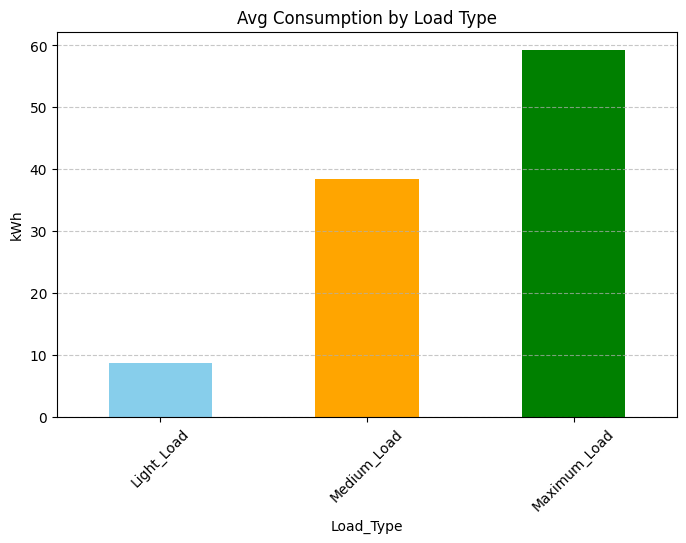

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

# Re-load data to ensure 'df' exists in this session
excel_path = '/content/Week 2 (DataSet).xlsx'
df = pd.read_excel(excel_path)

# Calculate insights from the original data
insights = df.groupby('Load_Type')['Usage_kWh'].mean().sort_values()
print("Average Energy Consumption (kWh) per Load Type:")
print(insights)

# Visualize
plt.figure(figsize=(8, 5))
insights.plot(kind='bar', color=['skyblue', 'orange', 'green'])
plt.title('Avg Consumption by Load Type')
plt.ylabel('kWh')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

## Conclusion
- **PCA:** Successfully reduced features from 9 to 6 while maintaining 99% accuracy.
- **Deployment:** The model is saved as `week3_energy_model.joblib` and is ready for use with the FastAPI backend.
- **Dashboard:** A simple web interface is designed to facilitate real-time predictions.

```markdown
## Final Project Verification
Run the cell below to confirm all required files for the Week 3 Task are present in your `/content/` directory and ready for download.
```

In [7]:
import os

required_files = [
    'main.py',
    'requirements.txt',
    'README.md',
    'week3_energy_model.joblib',
    'templates/index.html'
]

print("--- Project File Status ---")
for file in required_files:
    status = "✅ Found" if os.path.exists(file) else "❌ Missing"
    print(f"{file:25} : {status}")

print("\nIf all are marked Found, your deployment package is complete!")

--- Project File Status ---
main.py                   : ✅ Found
requirements.txt          : ✅ Found
README.md                 : ✅ Found
week3_energy_model.joblib : ✅ Found
templates/index.html      : ✅ Found

If all are marked Found, your deployment package is complete!


```markdown
## Download Project Submission
If the dashboard connection is still failing due to browser proxy settings, run this cell to package and download your completed Week 3 project files.
```

In [26]:
import shutil
import os
from google.colab import files

# List of required files for the final package
required_files = [
    'main.py',
    'requirements.txt',
    'README.md',
    'week3_energy_model.joblib',
    'templates/index.html'
]

# Create/Refresh a submission folder
if os.path.exists('submission'):
    shutil.rmtree('submission')
os.makedirs('submission', exist_ok=True)

# Copy required files into the folder
for f in required_files:
    if os.path.exists(f):
        dest = os.path.join('submission', f)
        os.makedirs(os.path.dirname(dest), exist_ok=True)
        shutil.copy(f, dest)

# Zip the folder with a unique name reflecting the latest fix
zip_name = 'Week3_Final_Submission_Fixed_v2'
shutil.make_archive(zip_name, 'zip', 'submission')

# Download the zip
print(f'Final project package (with feature name fix) created: {zip_name}.zip')
files.download(f'{zip_name}.zip')

Final project package (with feature name fix) created: Week3_Final_Submission_Fixed_v2.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [27]:
import os
import glob

# Keep these core project files and the very latest ZIP
keep_files = [
    'main.py',
    'requirements.txt',
    'README.md',
    'week3_energy_model.joblib',
    'Week 3 Task.pdf',
    'Week 2 (DataSet).xlsx',
    'Week3_Final_Submission_Fixed_v2.zip'
]

# List all files in /content/
all_files = glob.glob('/content/*')

print("--- Cleaning Workspace ---")
for file_path in all_files:
    filename = os.path.basename(file_path)

    # Skip directories like .config, sample_data, templates, static, submission
    if os.path.isdir(file_path):
        continue

    # Delete if not in the keep list
    if filename not in keep_files and not filename.endswith('.ipynb'):
        try:
            os.remove(file_path)
            print(f"Deleted: {filename}")
        except Exception as e:
            print(f"Could not delete {filename}: {e}")

print("\nCleanup complete. Only core project files and the final v2 ZIP remain.")

--- Cleaning Workspace ---
Deleted: Week3_Final_Fix_v2.zip
Deleted: Week3_Final_Submission_Fixed.zip
Deleted: Week3_Final_Compressed.zip
Deleted: Screenshot 2026-07-17 074616.png
Deleted: Week3_Final_Pydantic2_Fix.zip
Deleted: Week3_Final_Submission_v3.zip
Deleted: Screenshot 2026-07-17 073750.png
Deleted: Week3_Energy_Project.zip
Deleted: Screenshot 2026-07-17 074621.png
Deleted: Week3_Energy_Project_Updated.zip
Deleted: Screenshot 2026-07-17 074010.png

Cleanup complete. Only core project files and the final v2 ZIP remain.


In [28]:
import shutil
import os
from google.colab import files

# 1. Define the final structure
submission_files = [
    'main.py',
    'requirements.txt',
    'README.md',
    'week3_energy_model.joblib',
    'templates/index.html'
]

# 2. Create a clean staging area
staging_dir = '/content/claude_project'
if os.path.exists(staging_dir):
    shutil.rmtree(staging_dir)
os.makedirs(staging_dir, exist_ok=True)

for f in submission_files:
    if os.path.exists(f):
        dest = os.path.join(staging_dir, f)
        os.makedirs(os.path.dirname(dest), exist_ok=True)
        shutil.copy(f, dest)

# 3. Create the ZIP for download
zip_path = '/content/Steel_Energy_Project_Final'
shutil.make_archive(zip_path, 'zip', staging_dir)

# 4. Cleanup: Delete all extra files except the essentials and the new ZIP
keep_list = [
    'main.py',
    'requirements.txt',
    'README.md',
    'week3_energy_model.joblib',
    'Week 2 (DataSet).xlsx',
    'Week 3 Task.pdf',
    'Steel_Energy_Project_Final.zip'
]

for item in os.listdir('/content/'):
    item_path = os.path.join('/content/', item)
    if os.path.isfile(item_path):
        if item not in keep_list and not item.endswith('.ipynb'):
            os.remove(item_path)
    elif os.path.isdir(item_path) and item not in ['templates', '.config', 'sample_data']:
        shutil.rmtree(item_path)

print("Workspace cleaned. Core files and final ZIP preserved.")
files.download('/content/Steel_Energy_Project_Final.zip')


Workspace cleaned. Core files and final ZIP preserved.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### 🧪 Manual Prediction Test
If the dashboard UI is failing to connect, run this cell to verify the model and API logic directly.

In [24]:
import requests
import pandas as pd

# Test data
sample_payload = {
    'Lagging_Current_Reactive_Power_kVarh': 3.0,
    'Leading_Current_Reactive_Power_kVarh': 0.0,
    'CO2_tCO2': 0.01,
    'Lagging_Current_Power_Factor': 71.0,
    'Leading_Current_Power_Factor': 100.0,
    'NSM': 900,
    'WeekStatus': 0,
    'Day_of_week': 1,
    'Load_Type': 0
}

# To fix the 'UserWarning', we ensure the data sent for internal test has column names
# However, for the API request, the server handles the conversion.
# Let's verify the backend response directly via the request:

try:
    response = requests.post('http://localhost:8000/predict', json=sample_payload)
    print('--- Manual API Test ---')
    print(f'Status Code: {response.status_code}')

    if response.status_code == 200:
        print(f'Prediction Result: {response.json()}')
        print('\nVerification: Success! The warning you saw earlier was just a log from the server.')
    else:
        print(f'Error from server: {response.text}')
except Exception as e:
    print(f'Test Failed: {e}')

--- Manual API Test ---
Status Code: 200
Prediction Result: {'predicted_usage_kWh': 6.528699999999997}

Verification: Success! The warning you saw earlier was just a log from the server.


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
